In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# Backends (Fake providers)
* The fake provider module contains fake providers and fake backends classes. The fake backends are built to mimic the behaviors of IBM Quantum systems using system snapshots. The system snapshots contain important information about the quantum system such as coupling map, basis gates, qubit properties (T1, T2, error rate, etc.) which are useful for testing the transpiler and performing noisy simulations of the system.
* `qiskit.providers.fake_provider`
* List of fake providers at [Fake Providers](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider)
    * `FakeBrisbane`	A fake 127 qubit backend.
    * `FakeBrooklynV2`	A fake Brooklyn V2 backend.
    * `FakeCambridgeV2`	A fake Cambridge backend.
    * `FakeFez`	A fake 156 qubit backend.
    * `FakeJohannesburgV2`	A fake Johannesburg V2 backend.
    * `FakeKawasaki`	A fake 127 qubit backend.
    * `FakeKolkataV2`	A fake 27 qubit backend.
    * `FakeManilaV2`	A fake 5 qubit backend.

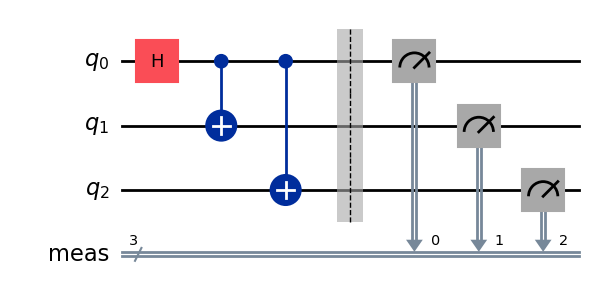

In [56]:
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
 
# Get a fake backend from the fake provider
backend = FakeManilaV2()
 
# Create a simple circuit
circuit = QuantumCircuit(3)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(0,2)
circuit.measure_all()
circuit.draw('mpl', style="iqp")

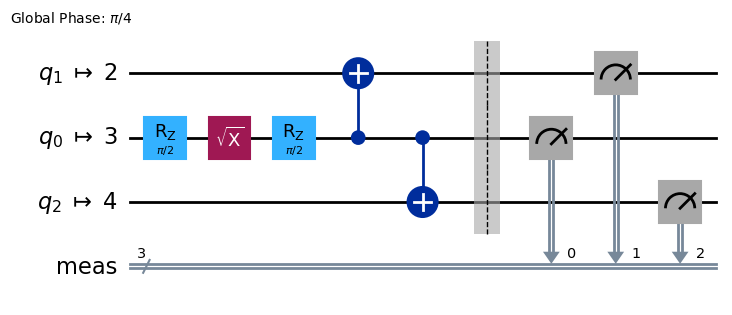

In [57]:
# Transpile the ideal circuit to a circuit that can be
# directly executed by the backend
transpiled_circuit = transpile(circuit, backend)
transpiled_circuit.draw('mpl', style="iqp")

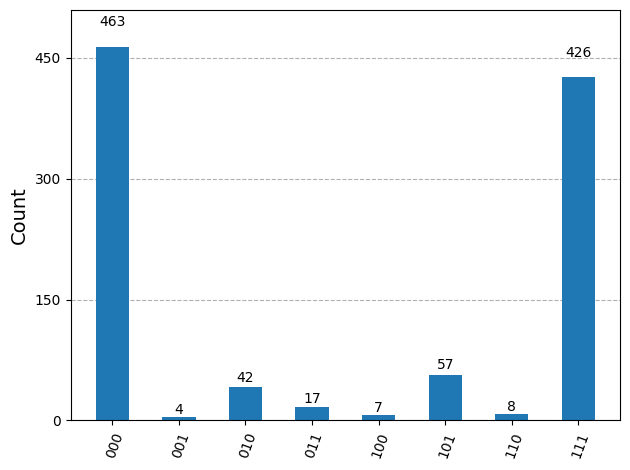

In [58]:
# Run the transpiled circuit using the simulated fake backend
sampler = SamplerV2(backend)
job = sampler.run([transpiled_circuit])
pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()
plot_histogram(counts)

# Backend
<img src="mapping.avif" alt="Circuit to physical qubits" width="50%">

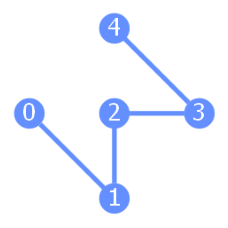

In [59]:
from qiskit.visualization import plot_gate_map

# qubit layout on system
plot_gate_map(backend)

In [55]:
backend_name = backend.backend_name
print(backend_name)
description = backend.description
print(description)
num_qubits = backend.num_qubits
print(num_qubits)
operations = backend.operation_names
print(operations)
instructions = backend.instructions
print(instructions)
coupling_map = backend.coupling_map
print(coupling_map)


options = backend.options
print(options)


fake_fez
156 qubit device
156
['measure', 'cz', 'delay', 'id', 'x', 'switch_case', 'rz', 'sx', 'reset', 'if_else', 'for_loop']
[(Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (0,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (1,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (2,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (3,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (4,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (5,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (6,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (7,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (8,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (9,)), (Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), (10,)), (Instruction(name='measure', num_qu

# Transpilation
<img src="transpiling_core_steps.avif" alt="Stages" width="50%">

* Transpilation is the process of rewriting a given input circuit to match the topology of a specific quantum device, and optimize the circuit instructions for execution on noisy quantum computers.

## Default transpilation
* For default transpilation, we use `qiskit.compiler.transpile`

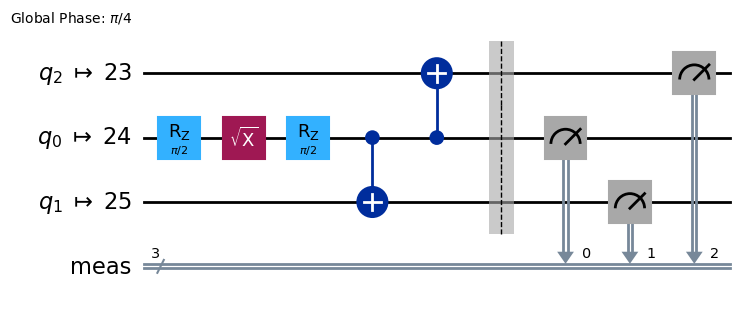

In [4]:
transpiled_circuit = transpile(circuit, backend)
transpiled_circuit.draw('mpl', style="iqp")

## Transpiler stages
Qiskit's prebuilt transpiler pipeline consists of six fundamental stages:

1. `init` - This pass runs any initial passes that are required before the circuit can be embedded. This typically involves unrolling custom instructions and converting the circuit to all single- and two-qubit gates. By default, this validates the circuit instructions and translates multi-qubit gates into single- and two-qubit gates.
2. `layout` - This pass applies a layout, mapping the virtual qubits in your circuit to the QPU's physical qubits.
3. `routing` - This pass runs after a layout has been applied and will inject gates (that is, SWAPs) in the original circuit to make it compatible with the QPU's connectivity (coupling map).
4. `translation` - This pass translates the gates in the circuit to the QPU's basis set of instructions.
5. `optimization` - This pass runs an optimization loop to find more efficient decompositions of the quantum circuit until a condition is met (such as a fixed depth).
6. `scheduling` - This stage is for any hardware-aware scheduling passes. If the user specifies a scheduling method, this stage accounts for all idle time in the circuit.

# Pass Managers
* A Pass is a single, specific transformation or analysis performed on your quantum circuit. In Qiskit, each pass has one job—it either changes the circuit or gathers information about it.
* There are two main types of passes:
    * Transformation Passes: These actually modify the circuit. (e.g., swapping a $Hadamard$ gate for $RZ$ and $SX$ gates).
    * Analysis Passes: These just "look" at the circuit to collect data (e.g., counting how many $CNOT$ gates are present) to help future passes make better decisions.
* Common examples of passes:
    * `Unroll3QOrMore`: Breaks down 3-qubit gates (like Toffoli) into 2-qubit gates.
    * `BasicSwap`: Inserts SWAP gates so the circuit fits the hardware's connectivity map.
    * `Optimize1qGates`: Look for adjacent single-qubit gates and merges them into one to reduce noise.
* The Pass Manager is a container that holds a list of passes and determines the order in which they run. This is crucial because the order matters: you can't optimize a circuit for a specific hardware's basis gates until you've first "unrolled" your complex gates into those basis gates.

In [17]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2

backend = FakeKolkataV2()

# Let's look at Level 3 (the most aggressive)
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

# To see every single pass in the pipeline:
for i, task in enumerate(pm.to_flow_controller().tasks):
    print(f"Step {i}: {task}")

Step 0: <qiskit.transpiler.passes.utils.contains_instruction.ContainsInstruction object at 0x000001967F56EC10>
Step 1: <qiskit.passmanager.flow_controllers.ConditionalController object at 0x000001967F533310>
Step 2: <qiskit.transpiler.passes.synthesis.unitary_synthesis.UnitarySynthesis object at 0x000001967A511BA0>
Step 3: <qiskit.transpiler.passes.synthesis.high_level_synthesis.HighLevelSynthesis object at 0x000001967A511CD0>
Step 4: <qiskit.transpiler.passes.basis.basis_translator.BasisTranslator object at 0x000001967C9FA2C0>
Step 5: <qiskit.transpiler.passes.optimization.elide_permutations.ElidePermutations object at 0x000001967F56EFD0>
Step 6: <qiskit.transpiler.passes.optimization.remove_diagonal_gates_before_measure.RemoveDiagonalGatesBeforeMeasure object at 0x000001967F56F110>
Step 7: <qiskit.transpiler.passes.optimization.remove_identity_equiv.RemoveIdentityEquivalent object at 0x000001967F56F250>
Step 8: <qiskit.transpiler.passes.optimization.inverse_cancellation.InverseCancel

* After a pass manager has been created, we can transpile the circuit using the pass manager.
* Note that automatic transpilation can happen using `transpile(circuit, backend)`.
* Pass manager provides better control.

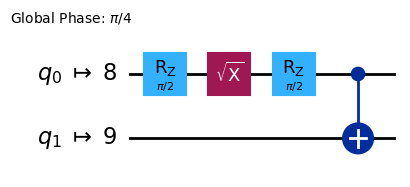

In [27]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
 
# Get a fake backend from the fake provider
backend = FakeKolkataV2()
 
# Any abstract circuit you want:
abstract = QuantumCircuit(2)
abstract.h(0)
abstract.cx(0, 1)
 
# Create the pass manager for the transpilation ...
pm = generate_preset_pass_manager(backend=backend)
# ... and use it (as many times as you like).
physical = pm.run(abstract)
physical.draw("mpl")

# Passes

## 1. Layout Selection (Placement)
*Determines how virtual qubits from your circuit are mapped to physical hardware qubits.*

| Pass | Description |
| :--- | :--- |
| **`SetLayout`** | Sets the `layout` property to a specific, user-defined layout. |
| **`TrivialLayout`** | Maps virtual qubit $i$ to physical qubit $i$ (no optimization). |
| **`DenseLayout`** | Finds the most connected subset of qubits to minimize gate distances. |
| **`SabreLayout`** | Uses a heuristic, bidirectional search to find a high-performance layout. |
| **`CSPLayout`** | Solves layout as a Constraint Satisfaction Problem (backtracking). |
| **`VF2Layout`** | Uses the VF2++ algorithm to find a perfect subgraph isomorphism if it exists. |
| **`ApplyLayout`** | Physically updates the circuit DAG based on a selected layout. |
| **`Layout2qDistance`** | **(Analysis)** Evaluates how "good" a layout is based on qubit distances. |



## 2. Routing
*Inserts SWAP gates to move quantum states across the chip to satisfy connectivity constraints.*

| Pass | Description |
| :--- | :--- |
| **`BasicSwap`** | Simple, greedy insertion of SWAPs to satisfy the coupling map. |
| **`SabreSwap`** | A look-ahead heuristic that significantly reduces the number of SWAPs needed. |
| **`LookaheadSwap`** | Uses a search algorithm to predict the cost of future gates. |
| **`Commuting2qGateRouter`** | Specialized routing for blocks of gates that commute. |
| **`LayoutTransformation`** | Applies a specific permutation to the qubits via SWAP circuits. |



## 3. Basis Change
*Translates abstract gates into the native gates (Basis Gates) of the target backend.*

| Pass | Description |
| :--- | :--- |
| **`BasisTranslator`** | Maps gates to the target basis using the `EquivalenceLibrary`. |
| **`Decompose`** | Expands complex gates into their fundamental definitions. |
| **`Unroll3qOrMore`** | Recursively breaks gates with $\geq 3$ qubits into 1 and 2-qubit gates. |
| **`UnrollCustomDefinitions`** | Expands user-defined gate instructions. |
| **`TranslateParameterizedGates`** | Handles the translation of gates containing symbolic variables. |



## 4. Optimizations
*Reduces gate count and circuit depth to improve performance and fight noise.*

| Pass | Description |
| :--- | :--- |
| **`Optimize1qGatesDecomposition`** | Collapses sequences of single-qubit gates into a single rotation. |
| **`CommutativeCancellation`** | Cancels redundant gates using commutation rules (e.g., $X \cdot X = I$). |
| **`InverseCancellation`** | Deletes pairs of back-to-back gates that are mathematical inverses. |
| **`OptimizeSwapBeforeMeasure`** | Re-routes the circuit to eliminate SWAPs occurring right before measurement. |
| **`RemoveIdentityEquivalent`** | Removes gates that have no effect (rotation angle $\approx 0$). |
| **`ConsolidateBlocks`** | Groups multiple gates into a single Unitary for re-synthesis. |
| **`RemoveDiagonalGatesBeforeMeasure`** | Deletes diagonal gates that don't change the $Z$-basis outcome. |



## 5. Scheduling & Noise Mitigation
*Manages the timing of gates to minimize decoherence and errors.*

| Pass | Description |
| :--- | :--- |
| **`ALAPScheduleAnalysis`** | Schedules gates "As Late As Possible" to minimize idle time. |
| **`ASAPScheduleAnalysis`** | Schedules gates "As Early As Possible." |
| **`PadDelay`** | Inserts explicit `Delay` instructions into idle qubit time-slots. |
| **`PadDynamicalDecoupling`** | Inserts pulse sequences (like $X-Y-X-Y$) to preserve qubit state. |
| **`ConstrainedReschedule`** | Adjusts timing to fit hardware pulse alignment constraints. |



## 6. Circuit Analysis
*Non-destructive passes that gather data about the circuit's complexity.*

| Pass | Description |
| :--- | :--- |
| **`Depth`** | Calculates the maximum number of sequential gates in the circuit. |
| **`Size`** | Returns the total number of gates. |
| **`Width`** | Returns the number of qubits (wires). |
| **`CountOps`** | Generates a dictionary of gate counts (e.g., `{'cx': 10, 'rz': 5}`). |
| **`DAGLongestPath`** | Identifies the critical path of gates through the circuit. |

# `generate_preset_pass_manager`
## Parameters

* `optimization_level` (`int`) – The optimization level to generate a StagedPassManager for. By default optimization level 2 is used if this is not specified. This can be 0, 1, 2, or 3. Higher levels generate potentially more optimized circuits, at the expense of longer transpilation time:
    * 0: no optimization
    * 1: light optimization
    * 2: heavy optimization
    * 3: even heavier optimization
* `backend` (`Backend`) – An optional backend object which can be used as the source of the default values for the `basis_gates`, `coupling_map`, and `target`. If any of those other arguments are specified in addition to `backend` they will take precedence over the value contained in the backend.

* `target` (`Target`) – The `Target` representing a backend compilation target. The following attributes will be inferred from this argument if they are not set: `coupling_map` and `basis_gates`.

* `basis_gates` (`list`) – List of basis gate names to unroll to (e.g: ['u1', 'u2', 'u3', 'cx']).

* `coupling_map` (`CouplingMap` or `list`) – Directed graph represents a coupling map. Multiple formats are supported:
    * `CouplingMap` instance
    * `List`, must be given as an adjacency matrix, where each entry specifies all directed two-qubit interactions supported by backend, e.g: [[0, 1], [0, 3], [1, 2], [1, 5], [2, 5], [4, 1], [5, 3]]
* `dt` (`float`) – Backend sample time (resolution) in seconds. If None (default) and a backend is provided, backend.dt is used.

* `initial_layout` (`Layout` | `List[int]`) – Initial position of virtual qubits on physical qubits.

* `layout_method` (`str`) – The `Pass` to use for choosing initial qubit placement. Valid choices are `'trivial'`, `'dense'`, and `'sabre'`, representing `TrivialLayout`, `DenseLayout` and `SabreLayout` respectively. This can also be the external plugin name to use for the layout stage of the output `StagedPassManager`. You can see a list of installed plugins by using `list_stage_plugins()` with `"layout"` for the `stage_name` argument.

* `routing_method` (`str`) – The pass to use for routing qubits on the architecture. Valid choices are `'basic'`, `'lookahead'`, `'sabre'`, and `'none'` representing `BasicSwap`, `LookaheadSwap`, `SabreSwap`, and erroring if routing is required respectively. This can also be the external plugin name to use for the routing stage of the output `StagedPassManager`. You can see a list of installed plugins by using `list_stage_plugins()` with `"routing"` for the `stage_name` argument.

* `translation_method` (`str`) – The method to use for translating gates to basis gates. Valid choices `'translator'`, `'synthesis'` representing `BasisTranslator`, and `UnitarySynthesis` respectively. This can also be the external plugin name to use for the translation stage of the output `StagedPassManager`. You can see a list of installed plugins by using `list_stage_plugins()` with `"translation"` for the `stage_name` argument.

* `scheduling_method` (`str`) – The pass to use for scheduling instructions. Valid choices are `'alap'` and `'asap'`. This can also be the external plugin name to use for the scheduling stage of the output `StagedPassManager`. You can see a list of installed plugins by using `list_stage_plugins()` with `"scheduling" `for the `stage_name` argument.

* `approximation_degree` (`float`) – Heuristic dial used for circuit approximation (1.0=no approximation, 0.0=maximal approximation).

* `seed_transpiler` (`int`) – Sets random seed for the stochastic parts of the transpiler.

* `unitary_synthesis_method` (`str`) – The name of the unitary synthesis method to use. By default `'default'` is used. You can see a list of installed plugins with `unitary_synthesis_plugin_names()`.

* `unitary_synthesis_plugin_config` (`dict`) – An optional configuration dictionary that will be passed directly to the unitary synthesis plugin. By default this setting will have no effect as the default unitary synthesis method does not take custom configuration. This should only be necessary when a unitary synthesis plugin is specified with the `unitary_synthesis_method` argument. 

* `hls_config` (`HLSConfig`) – An optional configuration class `HLSConfig` that will be passed directly to `HighLevelSynthesis` transformation pass. This configuration class allows to specify for various high-level objects the lists of synthesis algorithms and their parameters.

* `init_method` (`str`) – The plugin name to use for the init stage of the output `StagedPassManager`. By default an external plugin is not used. You can see a list of installed plugins by using `list_stage_plugins()` with `"init"` for the stage name argument.

* `optimization_method` (`str`) – The plugin name to use for the optimization stage of the output `StagedPassManager`. By default an external plugin is not used. You can see a list of installed plugins by using `list_stage_plugins()` with `"optimization"` for the `stage_name` argument.

* `qubits_initially_zero` (`bool`) – Indicates whether the input circuit is zero-initialized.

Text(0, 0.5, 'Counts')

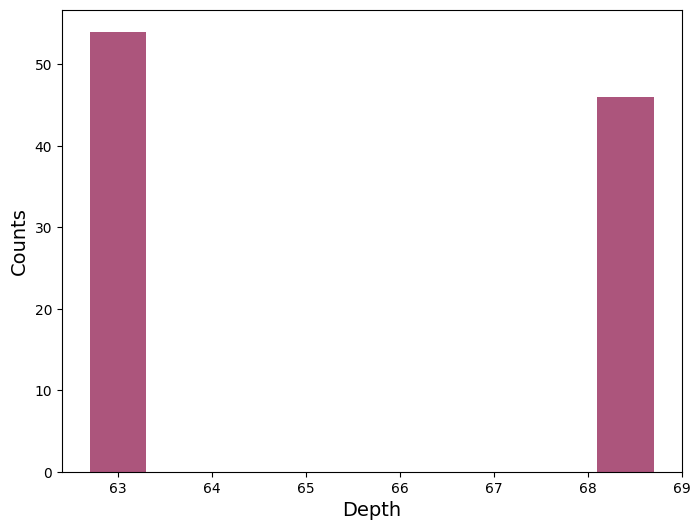

In [ ]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeWashingtonV2
from qiskit.transpiler import generate_preset_pass_manager

backend = FakeAuckland()

ghz = QuantumCircuit(15)
ghz.h(0)
ghz.cx(0, range(1, 15))

depths = []
for seed in range(100):
    pass_manager = (
        optimization_level=1,
        backend=backend,
        layout_method="trivial",  # Fixed layout mapped in circuit order
        seed_transpiler=seed,  # For reproducible results
    )
    depths.append(pass_manager.run(ghz).generate_preset_pass_managerdepth())

plt.figure(figsize=(8, 6))
plt.hist(depths, align="left", color="#AC557C")
plt.xlabel("Depth", fontsize=14)
plt.ylabel("Counts", fontsize=14)

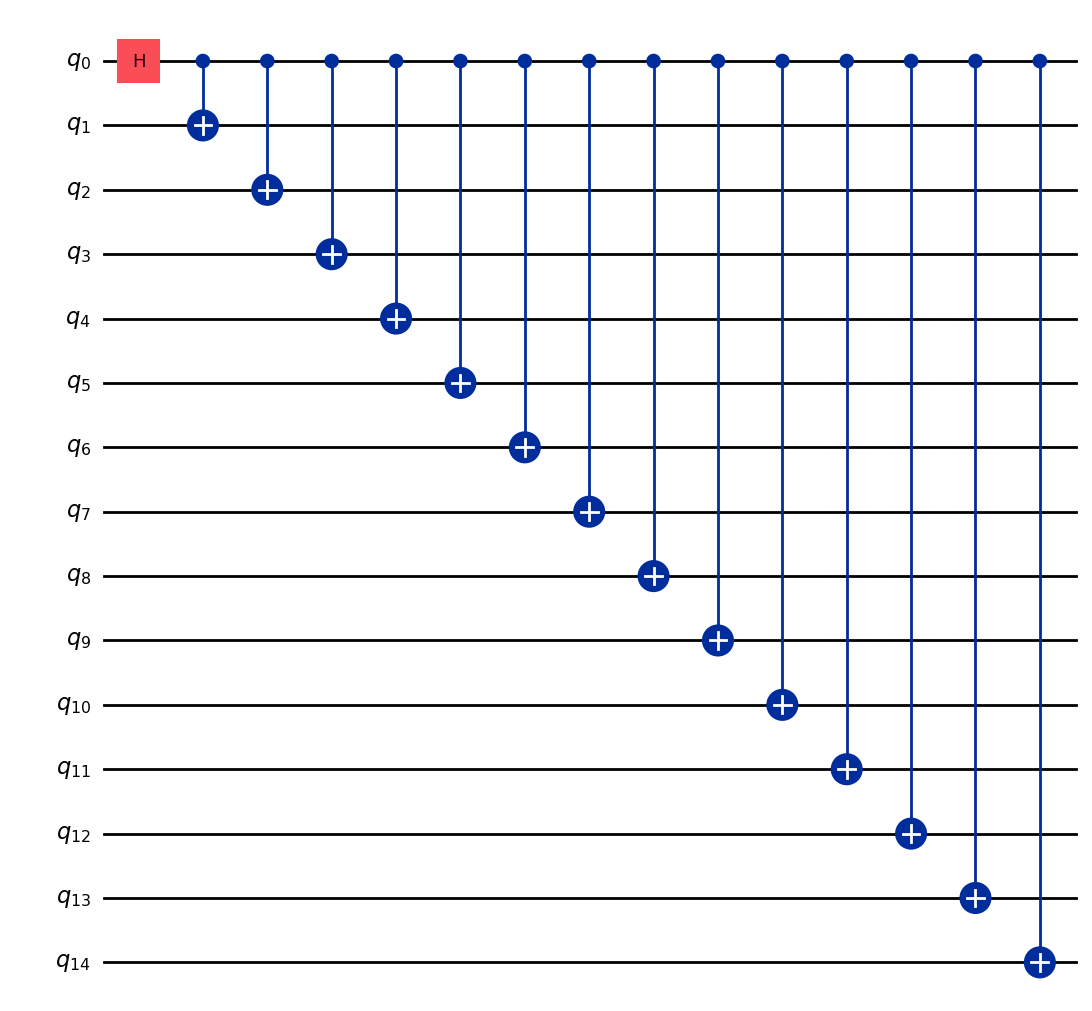

In [38]:
ghz.draw("mpl", idle_wires=False)

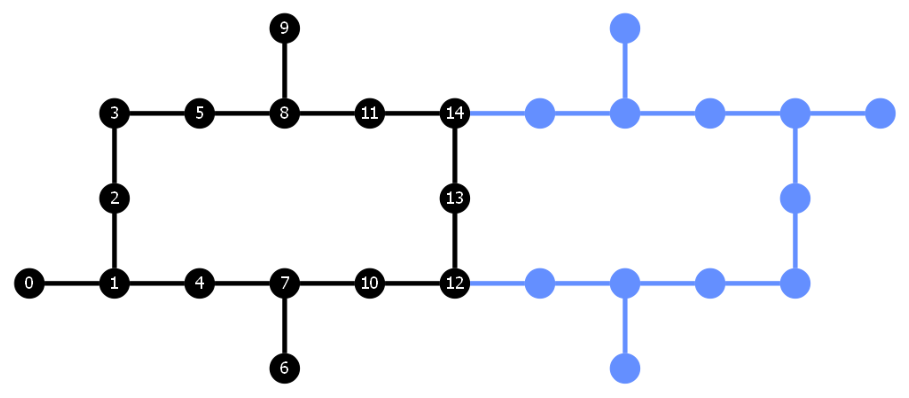

In [39]:
from qiskit.visualization import plot_circuit_layout

# Plot the hardware graph and indicate which hardware qubits were chosen to run the circuit
transpiled_circ = pass_manager.run(ghz)
plot_circuit_layout(transpiled_circ, backend)

In [40]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2

# 1. Setup Backend
backend = FakeKolkataV2()

# 2. Create a 6-qubit circuit with a "difficult" topology (a star/hub)
circuit = QuantumCircuit(6)
circuit.h(0)
for i in range(1, 6):
    circuit.cx(0, i)  # Qubit 0 is connected to everyone else
circuit.measure_all()

# 3. Use various options in generate_preset_pass_manager
# optimization_level: 0 (none) to 3 (aggressive)
# layout_method: 'trivial', 'dense', 'sabre'
# routing_method: 'basic', 'lookahead', 'sabre', 'none'
# translation_method: 'translator', 'synthesis'
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    layout_method='dense',    # Find the tightest cluster of 6 qubits on the chip
    routing_method='sabre',   # Use heuristic SWAP insertion for heavy-hex layout
    translation_method='synthesis', # Resynthesize blocks into basis gates
    seed_transpiler=42        # Ensures deterministic results
)

# 4. Execute
transpiled_circ = pm.run(circuit)

# 5. Review results
print(f"Backend: {backend.name}")
print(f"Final Depth: {transpiled_circ.depth()}")
print(f"Gate Counts: {transpiled_circ.count_ops()}")

# Check which physical qubits were chosen
layout = transpiled_circ.layout.initial_layout
for i, virt in enumerate(circuit.qubits):
    print(f"Virtual Qubit {i} -> Physical Qubit {layout[virt]}")

Backend: fake_kolkata
Final Depth: 28
Gate Counts: OrderedDict({'rz': 16, 'sx': 12, 'cx': 10, 'measure': 6, 'x': 2, 'barrier': 1})
Virtual Qubit 0 -> Physical Qubit 26
Virtual Qubit 1 -> Physical Qubit 22
Virtual Qubit 2 -> Physical Qubit 25
Virtual Qubit 3 -> Physical Qubit 24
Virtual Qubit 4 -> Physical Qubit 23
Virtual Qubit 5 -> Physical Qubit 21


# Custom Pass Managers

In [5]:
from qiskit.transpiler.passes import (
    UnitarySynthesis,
    Collect2qBlocks,
    ConsolidateBlocks,
    UnitarySynthesis,
    Unroll3qOrMore,
)
from qiskit.transpiler import PassManager, StagedPassManager
 
basis_gates = ["rx", "ry", "rxx"]
init = PassManager([UnitarySynthesis(basis_gates, min_qubits=3), Unroll3qOrMore()])
translate = PassManager(
    [
        Collect2qBlocks(),
        ConsolidateBlocks(basis_gates=basis_gates),
        UnitarySynthesis(basis_gates),
    ]
)
 
staged_pm = StagedPassManager(
    stages=["init", "translation"], init=init, translation=translate
)

# Low level details
## Target
* `Target` is the chip description of the QPU.

### Attributes

* `num_qubits`
* `physical_qubits` : returns a sorted list of physical qubits
* `instructions` : returns the list of tuples (`Insntruction, (qargs))
* `operations` : get the operation objects
* `operation_names` : A list of all supported gate names (e.g., ['cx', 'id', 'rz', 'sx', 'x', 'measure']).
* `qargs`: Returns all possible qubit combinations (tuples) that have at least one instruction defined on them.

### Methods

* `instruction_properties(instruction, qargs)` : retruns the duration and error rate for a specific gate on specific qubits **Usage**: `target.instruction_properties('cx', (0, 1))`
* `add_instruction` : add a new instruction to the target
* `build_coupling_map(two_q_gate=None, filter_idle_qubits=False)` : It scans every two-qubit gate in the target and generates a CouplingMap graph.
* `instruction_supported(instruction, qargs)` : A boolean check to see if the hardware can physically perform a specific gate on the requested qubits. This is what the transpiler uses to decide if it needs to insert SWAP gates.
* `instruction_supported(instruction, qargs)` : Returns names of instructions that are only available on specific qubits, which is helpful for identifying hardware asymmetries.

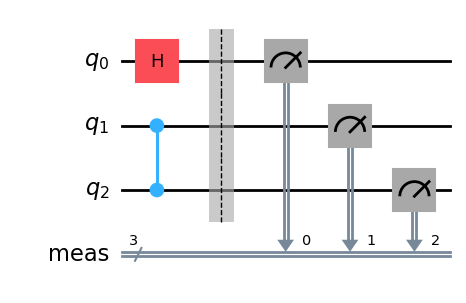

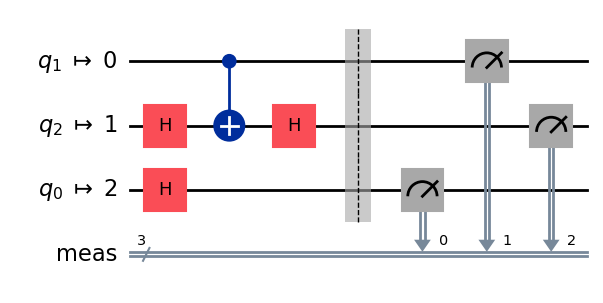

Target Qubits: 3
Target Basis Gates: dict_keys(['rx', 'h', 'cx', 'measure'])
Does it support CX(1,2)? False
------------------------------
Transpiled Circuit Depth: 4
Transpiled Ops: OrderedDict({'h': 3, 'measure': 3, 'cx': 1, 'barrier': 1})


In [ ]:
from qiskit import QuantumCircuit
from qiskit.transpiler import Target, InstructionProperties, generate_preset_pass_manager
from qiskit.circuit.library import HGate, RXGate, CXGate, Measure
from qiskit.circuit import Parameter
import math

# 1. Initialize an empty Target with 3 qubits
# dt: system time resolution in seconds
target = Target(num_qubits=3, dt=1e-9)

# 2. Define single-qubit instructions (RX Gate)
# We use a Parameter to show the gate is continuous (can take any theta)
theta = Parameter('theta')
rx_props = {
    (0,): InstructionProperties(duration=50e-9, error=0.001),
    (1,): InstructionProperties(duration=50e-9, error=0.001),
    (2,): InstructionProperties(duration=50e-9, error=0.002), # Qubit 2 is noisier
}
target.add_instruction(RXGate(theta), rx_props)

# H gate:
h_props = {
    (0,): InstructionProperties(duration=50e-9, error=0.001),
    (1,): InstructionProperties(duration=50e-9, error=0.001),
    (2,): InstructionProperties(duration=50e-9, error=0.002), # Qubit 2 is noisier
}
target.add_instruction(HGate(), h_props)
# 3. Define two-qubit instructions (CX Gate)
# This defines the "Coupling Map" implicitly. 
# Here, Qubit 0 can talk to 1 and 2, but 1 and 2 cannot talk to each other.
cx_props = {
    (0, 1): InstructionProperties(duration=300e-9, error=0.01),
    (0, 2): InstructionProperties(duration=400e-9, error=0.015),
}
target.add_instruction(CXGate(), cx_props)

# 4. Add Measurement
meas_props = {(i,): InstructionProperties(duration=1000e-9, error=0.05) for i in range(3)}
target.add_instruction(Measure(), meas_props)

# --- USING THE TARGET ---

# Create a circuit that requires connectivity we didn't provide (1 to 2)
circuit = QuantumCircuit(3)
circuit.h(0)
circuit.cz(1, 2) # This is NOT in our target!
circuit.measure_all()
display(circuit.draw("mpl"))

# Generate a PassManager that uses our custom Target
# The transpiler will see that (1,2) is missing and insert SWAPs via Qubit 0
pm = generate_preset_pass_manager(optimization_level=3, target=target)
transpiled_circuit = pm.run(circuit)
display(transpiled_circuit.draw("mpl"))

# Verify the results
print(f"Target Qubits: {target.num_qubits}")
print(f"Target Basis Gates: {target.operation_names}")
print(f"Does it support CX(1,2)? {target.instruction_supported('cx', (1, 2))}")
print("-" * 30)
print(f"Transpiled Circuit Depth: {transpiled_circuit.depth()}")
print(f"Transpiled Ops: {transpiled_circuit.count_ops()}")

## CouplingMap
* Directed graph specifying fixed coupling.

* Nodes correspond to physical qubits (integers) and directed edges correspond to permitted CNOT gates, with source and destination corresponding to control and target qubits, respectively.

### Attributes
* `distance_matrix`
* `is_symmetric`
* `physical_qubits`

### Methods
* `add_edge`
* `add_physical_qubit`
* `compute_distance_matrix`
* `connected_components`
* `distance`
* `draw`
* `get_edges`
* `size`
* `neighbors`

Number of qubits: 4
Is it connected? True
Physical distance between 0 and 2: 2


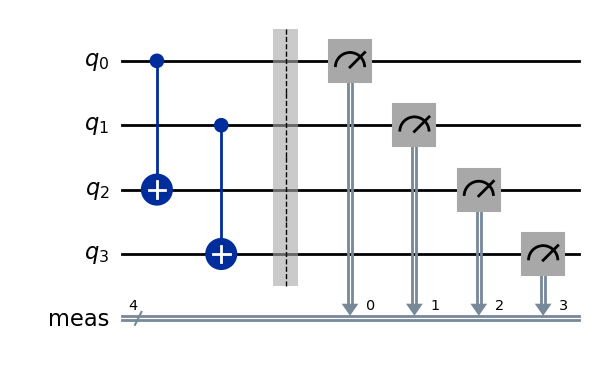

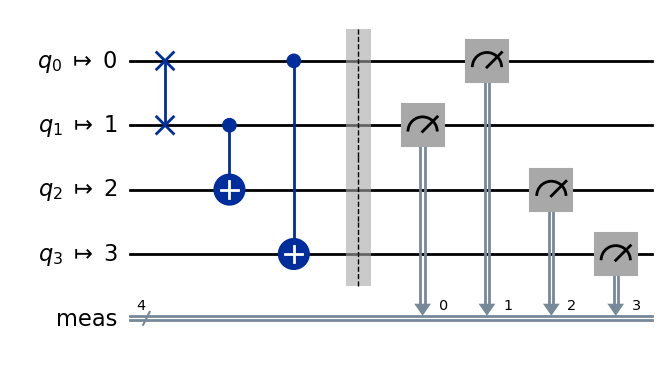

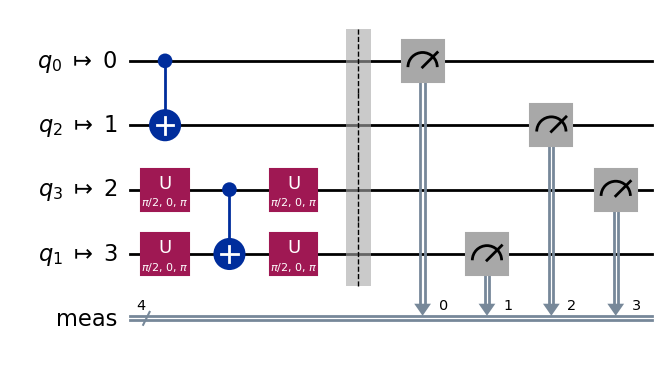

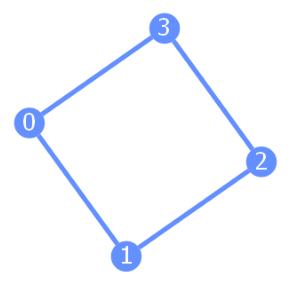

------------------------------
Original Depth: 2
Routed Depth (BasicSwap): 3
Routed Depth (Preset/Sabre): 4


In [3]:
from qiskit.transpiler import CouplingMap, PassManager, generate_preset_pass_manager
from qiskit.transpiler.passes import BasicSwap, SabreSwap
from qiskit import QuantumCircuit
from qiskit.visualization import plot_coupling_map

# 1. Create a Coupling Map
# You can define it manually via a list of edges [control, target]
# Let's build a ring: 0 -> 1 -> 2 -> 3 -> 0
edges = [[0, 1], [1, 2], [2, 3], [3, 0]]
cmap = CouplingMap(edges)

# 2. Inspect the map
print(f"Number of qubits: {cmap.size()}")
print(f"Is it connected? {cmap.is_connected()}")
print(f"Physical distance between 0 and 2: {cmap.distance(0, 2)}")

# 3. Create a circuit that violates this map
# We want to do a CX between 0 and 2, which are NOT directly connected
qc = QuantumCircuit(4)
qc.cx(0, 2)
qc.cx(1, 3)
qc.measure_all()

display(qc.draw("mpl"))

# 4. Use the CouplingMap in a PassManager
# Option A: Using the low-level pass directly
swap_pass = BasicSwap(coupling_map=cmap)
pm_basic = PassManager([swap_pass])
basic_circ = pm_basic.run(qc)

display(basic_circ.draw("mpl"))

# Option B: Using the modern Preset Pass Manager (Recommended)
pm_preset = generate_preset_pass_manager(
    optimization_level=1, 
    coupling_map=cmap,
    basis_gates=['u', 'cx']
)
preset_circ = pm_preset.run(qc)

display(preset_circ.draw("mpl"))

display(plot_coupling_map(num_qubits=4, qubit_coordinates=None, coupling_map=edges))

print("-" * 30)
print(f"Original Depth: {qc.depth()}")
print(f"Routed Depth (BasicSwap): {basic_circ.depth()}")
print(f"Routed Depth (Preset/Sabre): {preset_circ.depth()}")

#### Coupling map and Target

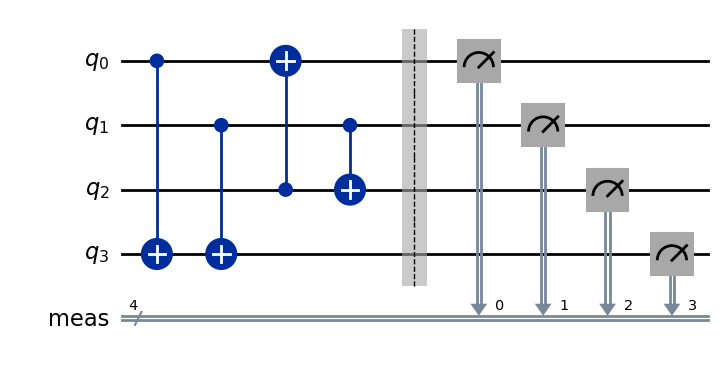

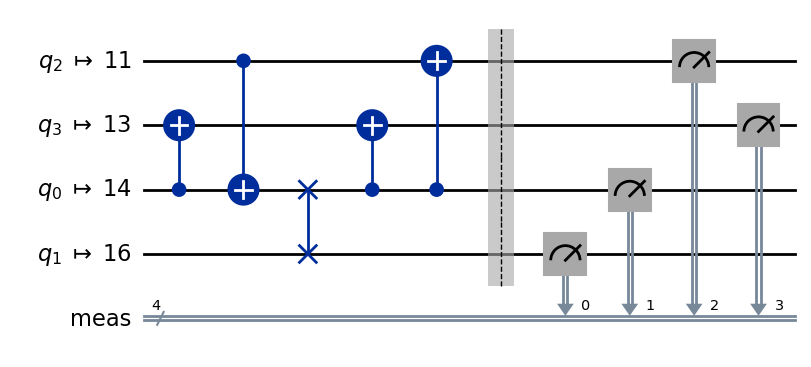

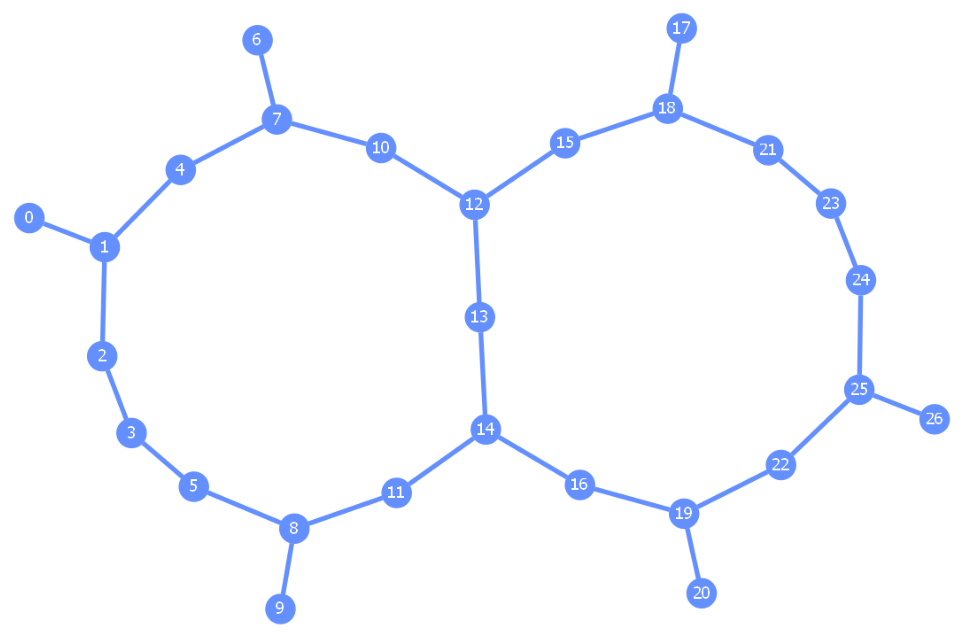

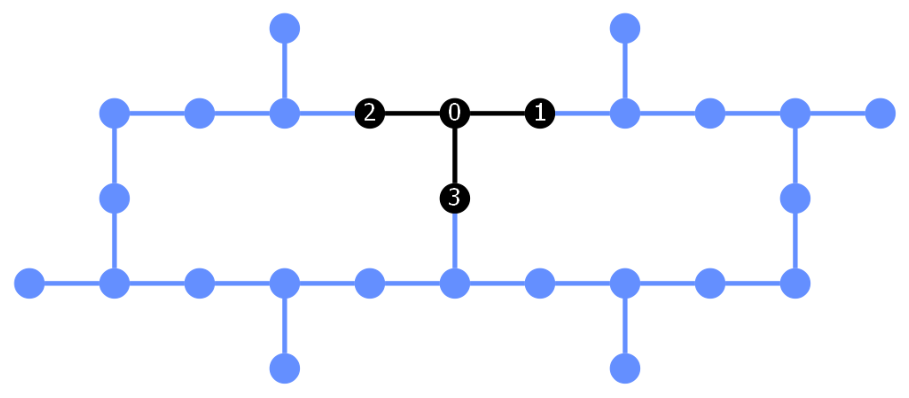

In [27]:
from qiskit.transpiler import Target, CouplingMap, PassManager
from qiskit.transpiler.passes import SabreLayout, SabreSwap
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
from qiskit.visualization import plot_circuit_layout


qc = QuantumCircuit(4)
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(2, 0)
qc.cx(1, 2)
qc.measure_all()

display(qc.draw("mpl"))


# 1. Setup Backend
backend = FakeKolkataV2()
# 1. Start with a Target (The "Full Package")
target = backend.target 

# 2. Extract the CouplingMap from the Target
# This combines all two-qubit gate connectivity into one graph
cmap = target.build_coupling_map()

# 3. Combine them in your PassManager
# SabreLayout uses the Target to find the "quietest" (lowest noise) qubits
layout_pass = SabreLayout(coupling_map=cmap)

# SabreSwap uses the CouplingMap to find the "shortest" path for SWAPs
routing_pass = SabreSwap(coupling_map=cmap)

pm = PassManager([layout_pass, routing_pass])
edges = cmap.get_edges()
passed_qc = pm.run(qc)
display(passed_qc.draw("mpl"))
display(plot_coupling_map(num_qubits=27, qubit_coordinates=None, coupling_map=edges))
display(plot_circuit_layout(passed_qc, backend))

* Notice that using SWAP the role of qubits is changed mid circuit.

# Custom passes

Original circuit:


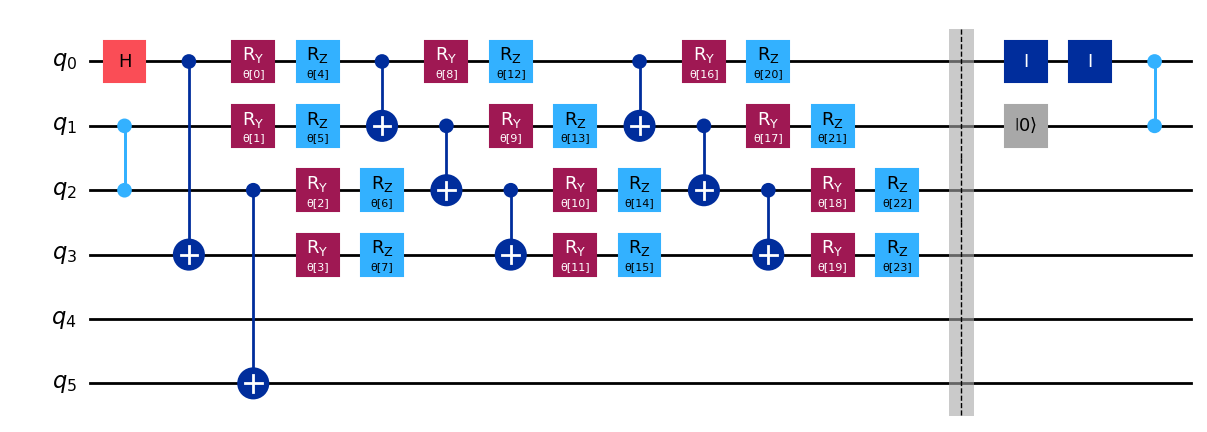

In [1]:
from qiskit import QuantumCircuit
from qiskit.transpiler import PassManager, StagedPassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import efficient_su2
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
from qiskit.circuit import SessionEquivalenceLibrary as sel

# 1. Fake 27-qubit backend (still valid in recent Qiskit)
backend = FakeKolkataV2()

# 2. Create a small circuit that triggers some init-stage clean-up
qc = QuantumCircuit(6)

# Some 1-qubit rotations + entangling gates
qc.h(0)
qc.cx(0, 3)
qc.cz(1, 2)
qc.cx(2, 5)

# Add a modern efficient SU(2) circuit (function style — recommended in 2.x)
qc.compose(
    efficient_su2(
        num_qubits=4,
        reps=2,
        entanglement="linear",
        name="su2_ansatz"
    ),
    qubits=[0, 1, 2, 3],
    inplace=True
)

qc.barrier()
qc.id(0)               # identity — should be removed in init
qc.id(0)               # duplicate
qc.reset(1)            # reset
qc.cz(0, 1)            # another gate after reset
# qc.measure_all()

print("Original circuit:")
display(qc.draw("mpl"))


# 3. Option A: Reuse the real built-in init stage (most realistic & up-to-date)
ref_pm = generate_preset_pass_manager(
    optimization_level=1,   # level 1–3 usually have good representative init passes
    backend=backend,
)


# Initialization stage
* At optimization level 0, no abstract optimization is done. The default plugin simply “unrolls” operations with more than three qubits by accessing their hierarchical definition fields.

* At optimization levels 1 and above, the default plugin also does simple cancellation of adjacent inverse gates, such as two back-to-back cx gates.

* At optimization levels 2 and 3, the default plugin enables a much wider range of abstract optimizations. This includes:
    * “Virtual permutation elision” (see `ElidePermutations`), where explicit permutation-inducing operations are removed and instead effected as remapping of virtual qubits.
    * Analysis of the commutation structure of the IR to find pairs of gates that can be canceled out.
    * Numerical splitting of two-qubit operations that can be expressed as a series of separable one-qubit operations.
    * Removal of imperceivable operations, such as tiny-angle Pauli rotations and diagonal operations immediately preceding measurements.


Passes in built-in 'init' stage (from preset level=1):

Circuit after ONLY init stage:


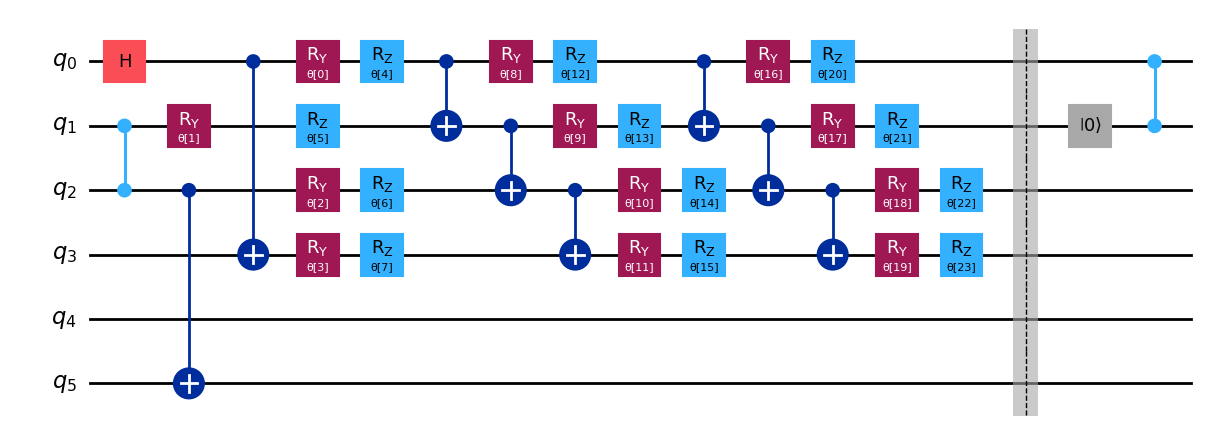


Original depth:    16
After init only:   15
Original ops:      OrderedDict({'ry': 12, 'rz': 12, 'cx': 8, 'cz': 2, 'id': 2, 'h': 1, 'barrier': 1, 'reset': 1})
After init ops:    OrderedDict({'ry': 12, 'rz': 12, 'cx': 8, 'cz': 2, 'h': 1, 'barrier': 1, 'reset': 1})


In [2]:

from qiskit.transpiler.passes import (
    RemoveIdentityEquivalent,
    Optimize1qGatesSimpleCommutation,
    UnrollCustomDefinitions,
    Unroll3qOrMore,
)

built_in_init = ref_pm.init

print("\nPasses in built-in 'init' stage (from preset level=1):")
print(built_in_init)

# 4. Option B: Explicit lightweight custom init (for learning / minimal control)
custom_init_passes = [
    RemoveIdentityEquivalent(),
    Optimize1qGatesSimpleCommutation(),     # merges simple 1q gates when possible
    UnrollCustomDefinitions(equivalence_library=sel,basis_gates=backend.operation_names),
    Unroll3qOrMore(),                       # decomposes >2q gates not natively supported
    # You can add more: Collect2qBlocks, ConsolidateBlocks, CommutationAnalysis, etc.
    # but these are the most common "early" init-style passes
]

light_init = PassManager(custom_init_passes)

# 5. Create StagedPassManager with ONLY init stage
pm_custom = StagedPassManager()
# pm_only_init.init = built_in_init          # ← recommended: use real one
pm_custom.init = light_init           # ← or use the explicit version

# 6. Run only the init stage
qc_after_init = pm_custom.run(qc)

print("\nCircuit after ONLY init stage:")
display(qc_after_init.draw("mpl"))

# Quick comparison
print(f"\nOriginal depth:    {qc.depth()}")
print(f"After init only:   {qc_after_init.depth()}")
print(f"Original ops:      {qc.count_ops()}")
print(f"After init ops:    {qc_after_init.count_ops()}")

# Layout stage
* At any given point in a circuit, we can identify a mapping between currently active “virtual” qubits of the input circuit to hardware qubits of the backend. A hardware qubit can only ever represent a single virtual qubit at a given point, but the mapping might vary over the course of the circuit. In principle, some virtual qubits might not be mapped at all points in the circuit execution, if the lifetime of a virtual qubit state can be shortened, though Qiskit’s built-in pipelines do not use this currently.
* The choice of initial layout is one of the most important factors that affects the quality of the output circuit. The layout stage is often the most computationally expensive stage in the default pipelines; the default plugin for layout even tries several different algorithms

## Built-in pluggins for layout
* `default` : At the highest optimization levels, attempts to find a perfect layout, then tries a Sabre-based layout-and-routing combined pass.
* `dense` : Finds the densest subgraph (in terms of qubit link degrees) of the backend to use as the initial qubits.
* `trivial` : Maps virtual qubit 0 to physical qubit 0, and so on.
* `sabre` : Sabre layout algorithm


Passes included in the layout stage:


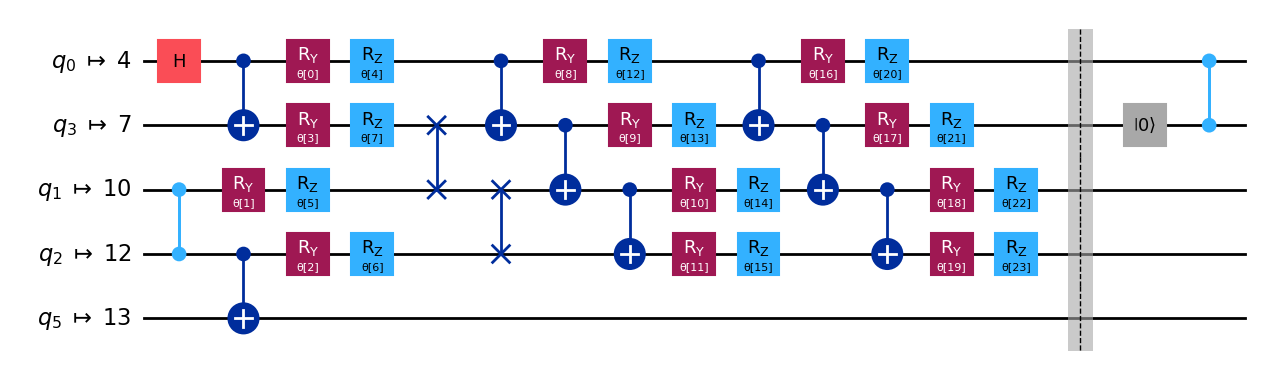


Initial layout (virtual → physical):
TranspileLayout(initial_layout=Layout({
4: <Qubit register=(6, "q"), index=0>,
10: <Qubit register=(6, "q"), index=1>,
12: <Qubit register=(6, "q"), index=2>,
7: <Qubit register=(6, "q"), index=3>,
1: <Qubit register=(6, "q"), index=4>,
13: <Qubit register=(6, "q"), index=5>,
0: <Qubit register=(21, "ancilla"), index=0>,
2: <Qubit register=(21, "ancilla"), index=1>,
3: <Qubit register=(21, "ancilla"), index=2>,
5: <Qubit register=(21, "ancilla"), index=3>,
6: <Qubit register=(21, "ancilla"), index=4>,
8: <Qubit register=(21, "ancilla"), index=5>,
9: <Qubit register=(21, "ancilla"), index=6>,
11: <Qubit register=(21, "ancilla"), index=7>,
14: <Qubit register=(21, "ancilla"), index=8>,
15: <Qubit register=(21, "ancilla"), index=9>,
16: <Qubit register=(21, "ancilla"), index=10>,
17: <Qubit register=(21, "ancilla"), index=11>,
18: <Qubit register=(21, "ancilla"), index=12>,
19: <Qubit register=(21, "ancilla"), index=13>,
20: <Qubit register=(21, "anci

In [ ]:
from qiskit.transpiler.passes import (
    TrivialLayout,
    VF2Layout,
    DenseLayout,
    ApplyLayout,
    SabreLayout,               # often used in higher optimization levels
    VF2PostLayout,             # optional: post-routing layout improvement
)
# Option A: Explicit / custom layout stage with common passes
layout_passes_explicit = [
    TrivialLayout(coupling_map=backend.coupling_map),
    VF2Layout(
        target=backend.target,
        # coupling_map=backend.coupling_map,
        # properties=backend.properties(),
        max_trials=2500,                # increase if you want more thorough search
        strict_direction=True,
    ),
    DenseLayout(
        target=backend.target
    ),
    ApplyLayout(),
]

custom_layout_stage = PassManager(layout_passes_explicit)
built_in_layout_stage = ref_pm.layout
pm_custom.layout = built_in_layout_stage
print("\nPasses included in the layout stage:")
print(pm_custom.layout)
# === After running the pass manager, you can inspect the chosen layout ===
qc_after_init_layout = pm_custom.run(qc)
display(qc_after_init_layout.draw("mpl"))
# Show the virtual → physical qubit mapping that was applied
if qc_after_init_layout.layout:
    print("\nInitial layout (virtual → physical):")
    print(qc_after_init_layout.layout)

# Routing stage



Passes included in the routing stage (preset with routing_method='sabre'):

Circuit after full pipeline (including routing):


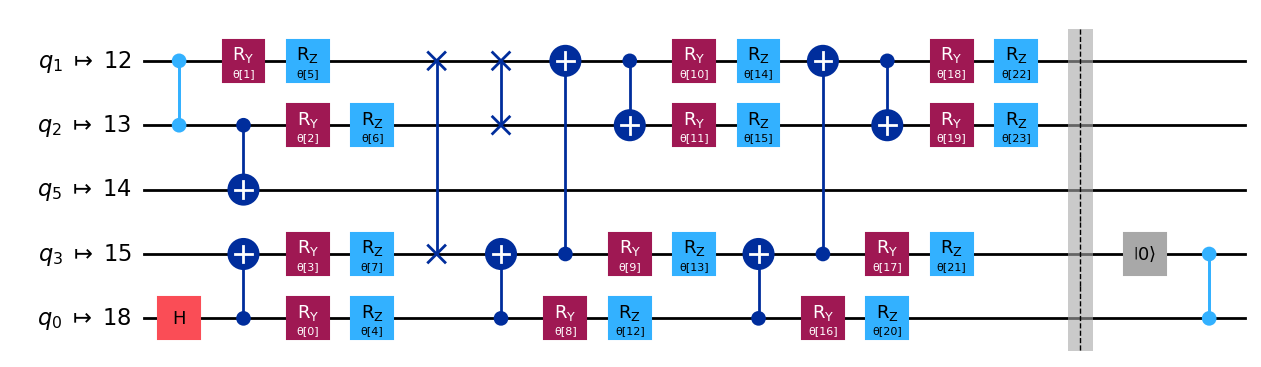

Depth after routing: 16
Operations: OrderedDict({'ry': 12, 'rz': 12, 'cx': 8, 'cz': 2, 'swap': 2, 'h': 1, 'barrier': 1, 'reset': 1})


In [8]:
from qiskit.transpiler.passes import (
    SabreSwap,                 # most common heuristic routing in 2.x presets
    CommutationAnalysis,       # often used before/after routing
    VF2PostLayout,             # optional: improves layout after routing (common in level 2–3)
)
# === Create routing stage — two main options ===

# Option A: Explicit / custom routing stage (SabreSwap is default in many presets)
routing_passes_explicit = [
    CommutationAnalysis(),             # helps SabreSwap by knowing commuting gates
    SabreSwap(
        coupling_map=backend.coupling_map,
        # trials=..., seed_transpiler=..., max_iterations=...  # tune if needed
    ),
    # Optional: improve layout after routing (fidelity-aware)
    # VF2PostLayout(
    #     target=backend.target,
    #     strict_direction=True,         # respect CX/ECR direction
    #     # max_trials=..., seed=...
    # ),
    # Optional: if you want to re-apply layout after post-routing improvement
    # ApplyLayout(),
]

custom_routing_stage = PassManager(routing_passes_explicit)


# Option B: Reuse built-in routing stage (recommended — matches preset behavior)
ref_pm = generate_preset_pass_manager(
    optimization_level=2,              # 1–3; higher often uses Sabre + VF2PostLayout
    backend=backend,
    routing_method="sabre",            # "sabre" (default), "basic", "lookahead", "none", or plugin name
    # seed_transpiler=42,              # optional for reproducibility
)

built_in_routing_stage = ref_pm.routing

print("\nPasses included in the routing stage (preset with routing_method='sabre'):")
print(built_in_routing_stage)

pm_custom.routing = custom_routing_stage

# === Run and inspect (now with routing) ===
qc_routed = pm_custom.run(qc)   # or qc_final if you want to overwrite

print("\nCircuit after full pipeline (including routing):")
display(qc_routed.draw("mpl", idle_wires=False))

# Quick checks
print("Depth after routing:", qc_routed.depth())
print("Operations:", qc_routed.count_ops())

# Translation stage
* The translation stage is responsible for rewriting all gates in the circuit into ones that are supported by the target ISA. For example, if a `cx` is requested on hardware qubits 0 and 1, but the ISA only contains a `cz` operation on those qubits, the translation stage must find a way of representing the `cx` gate using the `cz` and available one-qubit gates.

## Built-in pluggins for translation
* `default` :	Use a Qiskit-chosen default translation method.
* `translator` :	Symbolic translation of gates to the target basis using known equivalences.
* `synthesis` :	Collect each run of one- and two-qubit gates into a matrix representation, and resynthesize from there.


Passes included in the translation stage:

Circuit after init + layout + translation stages:


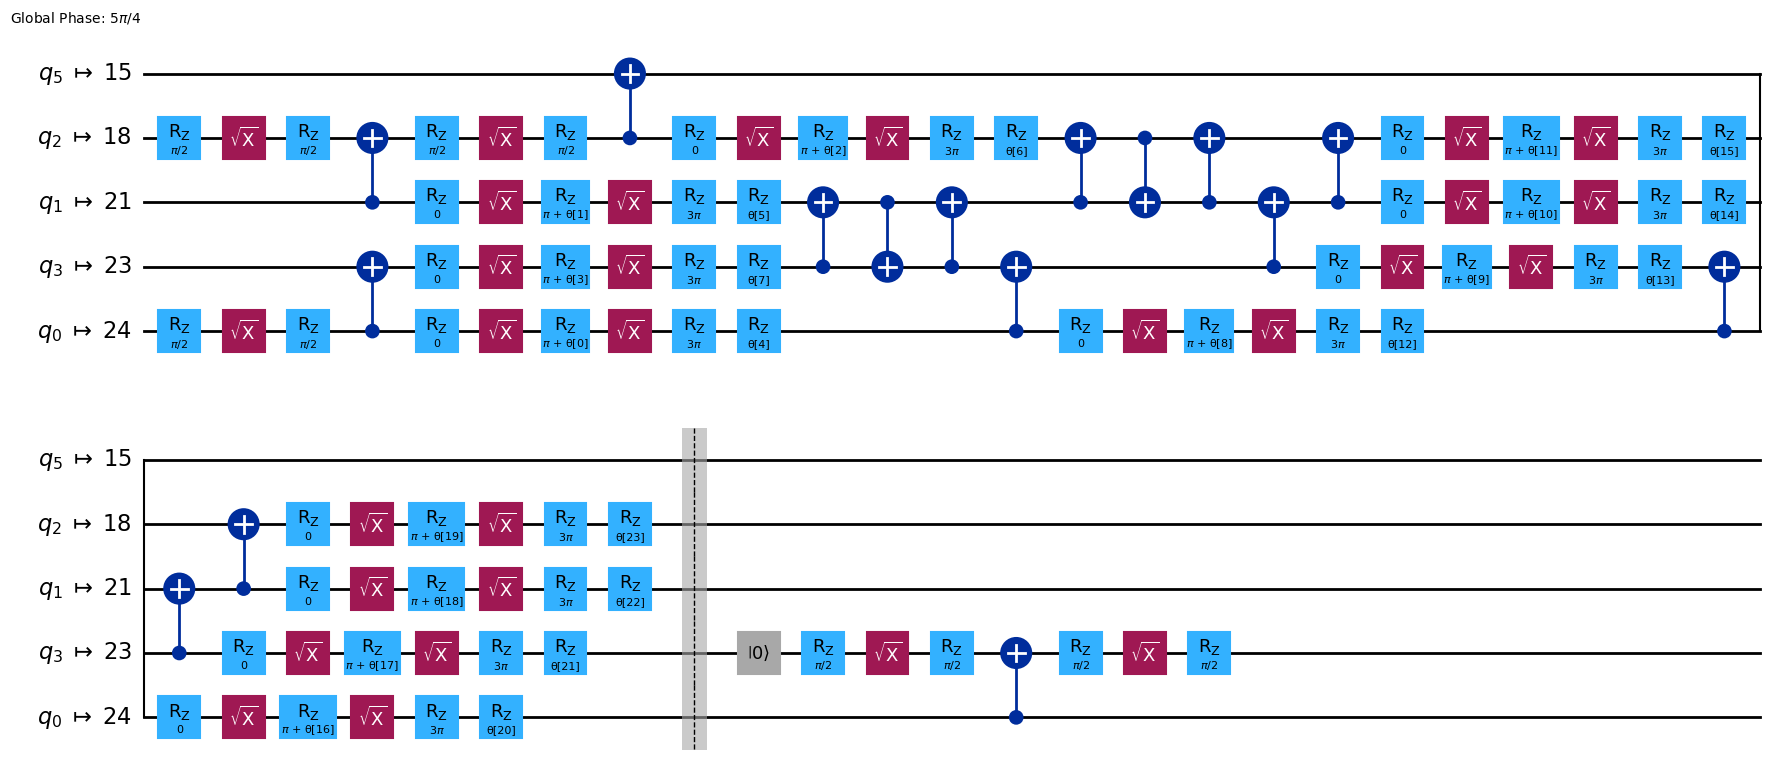


Operations after translation:
OrderedDict({'rz': 58, 'sx': 29, 'cx': 16, 'barrier': 1, 'reset': 1})


In [9]:
from qiskit.transpiler.passes import (
    HighLevelSynthesis,          # often first in translation — synthesizes high-level objects
    BasisTranslator,             # core translation pass (uses equivalence rules)
    UnitarySynthesis,            # alternative/more aggressive synthesis (used in some modes)
)
# === Create translation stage — two main options ===

# Option A: Explicit / custom translation stage (common in "translator" method)
translation_passes_explicit = [
    BasisTranslator(                   # main symbolic translation to target basis
        equivalence_library=sel,       # SessionEquivalenceLibrary (from earlier)
        target=backend.target, 
        target_basis=backend.operation_names        # or basis_gates=backend.operation_names
    ),
    # Optional extras depending on needs:
    # Optimize1qGatesSimpleCommutation(),  # sometimes placed here in custom flows
    # UnitarySynthesis(                    # if you want unitary-level resynthesis
    #     basis_gates=backend.operation_names,
    #     approximation_degree=1.0,
    # ),
]

custom_translation_stage = PassManager(translation_passes_explicit)


# Option B: Reuse built-in translation stage (recommended — matches preset behavior)
ref_pm = generate_preset_pass_manager(
    optimization_level=2,              # 1–3 usually give representative translation
    backend=backend,
    translation_method="translator",   # or "synthesis" / "default"
    # approximation_degree=0.99,       # optional: if you want approximate synthesis
)

built_in_translation_stage = ref_pm.translation
pm_custom.translation = custom_translation_stage
print("\nPasses included in the translation stage:")
print(built_in_translation_stage)
# === Run and inspect ===
qc_after_init_layout_translation = pm_custom.run(qc)

print("\nCircuit after init + layout + translation stages:")
display(qc_after_init_layout_translation.draw("mpl"))

# Quick check: all gates should now be in backend's basis (except measure/reset/barriers)
print("\nOperations after translation:")
print(qc_after_init_layout_translation.count_ops())

# Optimization stage
* At optimization level 0, the stage is empty.

* At optimization level 1, the stage does matrix-based resynthesis of runs of single-qubit gates, and very simple symbolic inverse cancellation of two-qubit gates, if they appear consecutively. This runs in a loop until the size and depth of the circuit are fixed.

* At optimization level 2, in addition the optimizations of level 1, the loop contains commutation analysis of sets of gates to widen the range of gates that can be considered for cancellation. Before the loop, runs of both one- and two-qubit gates undergo a single matrix-based resynthesis.

* At optimization level 3, the two-qubit matrix-based resynthesis runs inside the optimization loop. The optimization loop condition also tries multiple runs and chooses the minimum point in the case of fluctuating output; this is necessary because matrix-based resynthesis is relatively unstable in terms of concrete gates.


Passes included in the optimization stage (preset level=2):

Circuit after init + layout + translation + optimization stages:


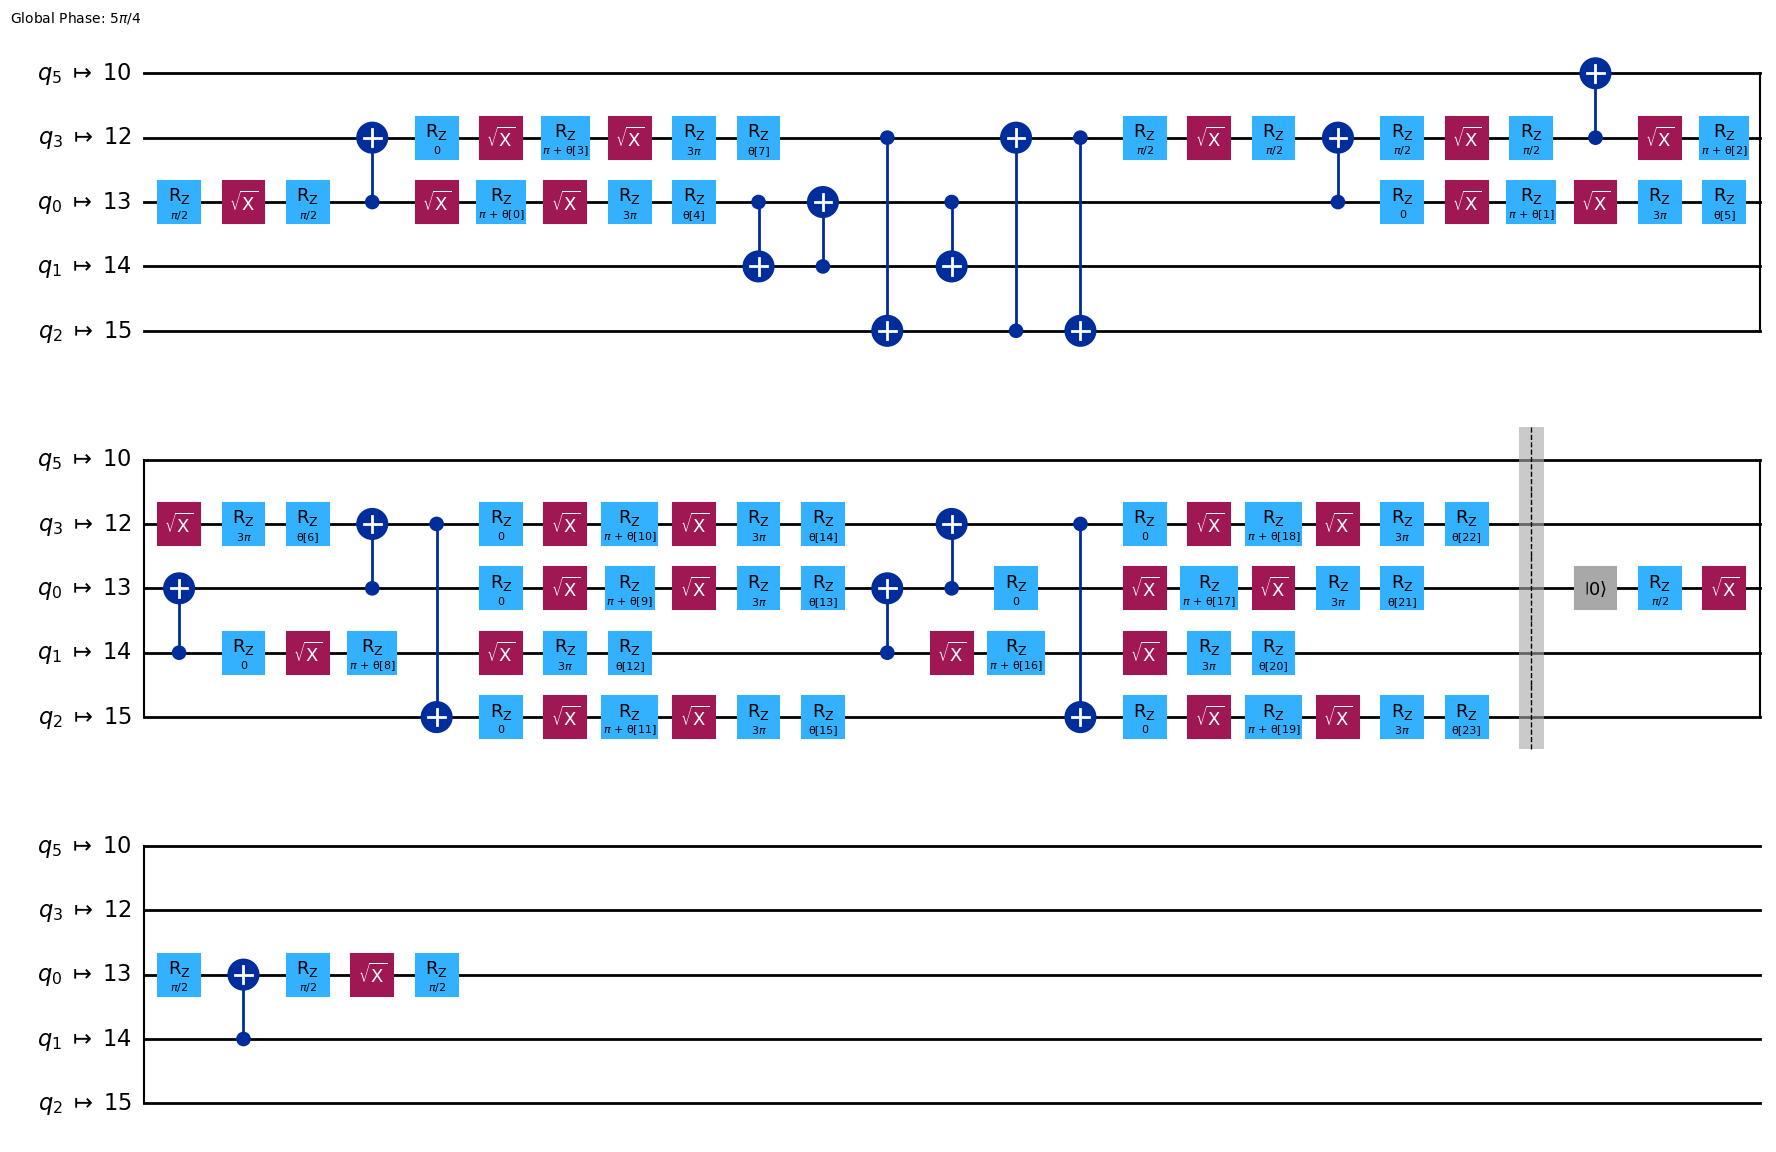


Operations count comparison:
Original:           OrderedDict({'ry': 12, 'rz': 12, 'cx': 8, 'cz': 2, 'id': 2, 'h': 1, 'barrier': 1, 'reset': 1})
After optimization: OrderedDict({'rz': 55, 'sx': 29, 'cx': 16, 'barrier': 1, 'reset': 1})
Depth comparison:   16 → 50


In [ ]:
from qiskit.transpiler.passes import (
    Optimize1qGates,                    # merges / simplifies 1q gate chains
    Optimize1qGatesSimpleCommutation,   # lighter 1q optimization (often early)
    CommutativeCancellation,            # cancels self-inverse gates via commutation
    InverseCancellation,                     # cancels consecutive CX gates (level 1 style)
    RemoveResetInZeroState,             # removes useless resets
    # Optional / more advanced (common in level 2–3):
    Collect2qBlocks,
    ConsolidateBlocks,
    CommutationAnalysis,                # prerequisite for many cancellation passes
)
# === Create optimization stage — two main options ===

# Option A: Explicit / custom optimization stage (typical for level 2)
optimization_passes_explicit = [
    CommutationAnalysis(),                  # analyze what commutes (needed for CommutativeCancellation)
    CommutativeCancellation(),              # cancel non-adjacent self-inverse gates
    Optimize1qGates(),                      # merge/simplify chains of 1q gates
    InverseCancellation(),                       # cancel consecutive CX gates
    RemoveResetInZeroState(),               # clean useless resets
    # You can add more blocks for deeper optimization (level 3 style):
    # Collect2qBlocks(),
    # ConsolidateBlocks(),
    # Optimize1qGates(),  # run again after block consolidation
]

custom_optimization_stage = PassManager(optimization_passes_explicit)


# Option B: Reuse built-in optimization stage (recommended — closest to preset behavior)
ref_pm = generate_preset_pass_manager(
    optimization_level=2,              # try 1, 2 or 3 — changes passes significantly
    backend=backend,
    # translation_method="translator", # optional — influences if extra opts appear
)

built_in_optimization_stage = ref_pm.optimization

print("\nPasses included in the optimization stage (preset level=2):")
print(built_in_optimization_stage)

pm_custom.optimization = custom_optimization_stage
qc_after_opt = pm_custom.run(qc)

print("\nCircuit after init + layout + translation + optimization stages:")
display(qc_after_opt.draw("mpl"))

print("\nOperations count comparison:")
print("Original:          ", qc.count_ops())
print("After optimization:", qc_after_opt.count_ops())
print("Depth comparison:  ", qc.depth(), "→", qc_after_opt.depth())

# Scheduling stage
* The scheduling stage, if requested, is responsible for inserting explicit Delay instructions to make idle periods of qubits explicit. Plugins may optionally choose to do walltime-sensitive transformations, such as inserting dynamical decoupling sequences.

## Built-in pluggins for scheduling
* `default` :	Attempt to satisfy timing alignment constraints without otherwise scheduling.
* `alap` :	Schedule the circuit, preferring operations to be as late as possible.
* `asap` :	Schedule the circuit, preferring operations to be as soon as possible.

# Manual Layout

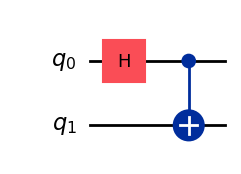

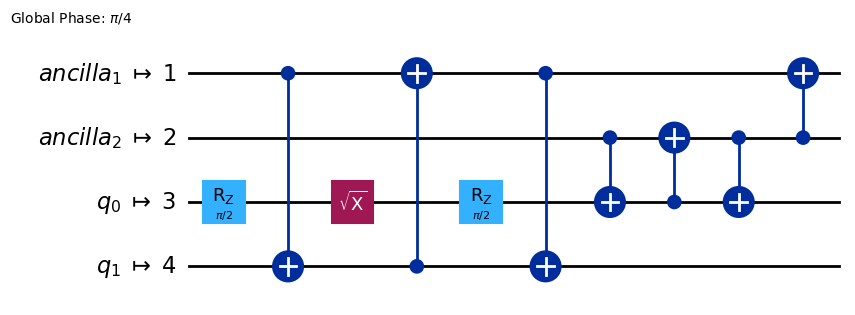

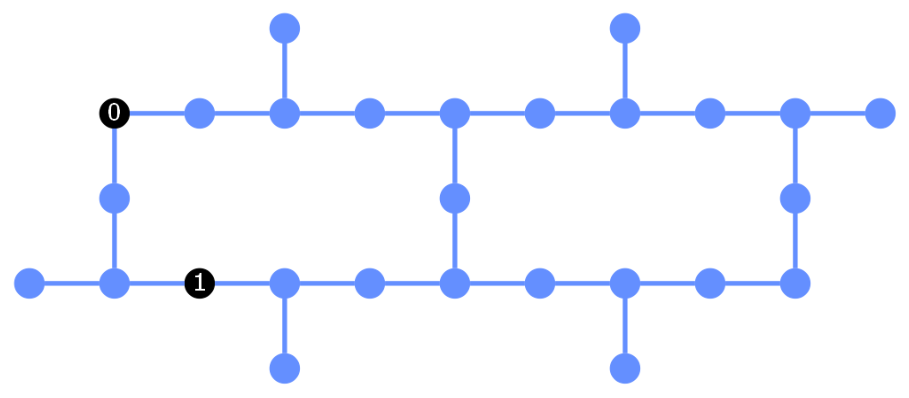

Initial Layout: Layout({
3: <Qubit register=(2, "q"), index=0>,
4: <Qubit register=(2, "q"), index=1>,
0: <Qubit register=(25, "ancilla"), index=0>,
1: <Qubit register=(25, "ancilla"), index=1>,
2: <Qubit register=(25, "ancilla"), index=2>,
5: <Qubit register=(25, "ancilla"), index=3>,
6: <Qubit register=(25, "ancilla"), index=4>,
7: <Qubit register=(25, "ancilla"), index=5>,
8: <Qubit register=(25, "ancilla"), index=6>,
9: <Qubit register=(25, "ancilla"), index=7>,
10: <Qubit register=(25, "ancilla"), index=8>,
11: <Qubit register=(25, "ancilla"), index=9>,
12: <Qubit register=(25, "ancilla"), index=10>,
13: <Qubit register=(25, "ancilla"), index=11>,
14: <Qubit register=(25, "ancilla"), index=12>,
15: <Qubit register=(25, "ancilla"), index=13>,
16: <Qubit register=(25, "ancilla"), index=14>,
17: <Qubit register=(25, "ancilla"), index=15>,
18: <Qubit register=(25, "ancilla"), index=16>,
19: <Qubit register=(25, "ancilla"), index=17>,
20: <Qubit register=(25, "ancilla"), index=18>,
21:

In [12]:
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeKolkataV2
from qiskit.visualization import plot_circuit_layout

# Your virtual circuit (2 qubits)
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

display(qc.draw("mpl"))
backend = FakeKolkataV2()

# Force Virtual q0 -> Physical Q3 and Virtual q1 -> Physical Q4
my_layout = [3, 4] 

pm = generate_preset_pass_manager(
    optimization_level=3, 
    backend=backend, 
    initial_layout=my_layout
)

transpiled_qc = pm.run(qc)
display(transpiled_qc.draw("mpl"))
display(plot_circuit_layout(transpiled_qc, backend))
# Verify the mapping
print(f"Initial Layout: {transpiled_qc.layout.initial_layout}")